In [1]:
# 1a.

# import pandas.
import pandas as pd

# load data.
df = pd.read_csv('us_pop_data.csv')

# add 'years_since_1790' column
df['years_since_1790'] = df['year']-1790

# add us_pop_mil column
df['us_pop_mil'] = df['us_pop'] / 1000000

df.head()

,year,us_pop,years_since_1790,us_pop_mil
0,1790,3929326,0,3.929326
1,1800,5308483,10,5.308483
2,1810,7239881,20,7.239881
3,1820,9638453,30,9.638453
4,1830,12866020,40,12.866020


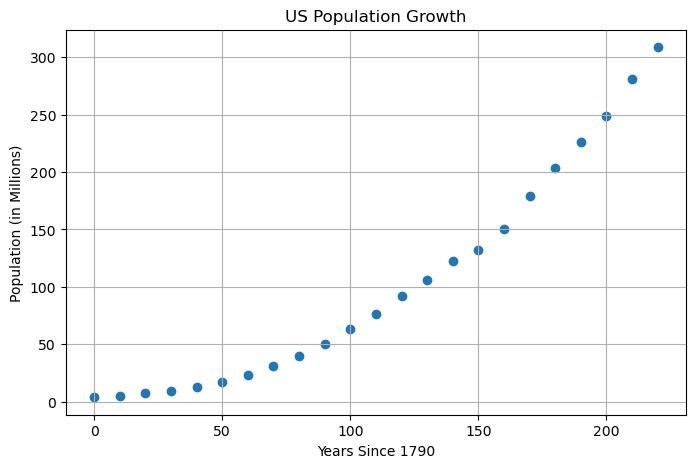

In [2]:
#1b.

# import matplotlib
import matplotlib.pyplot as plt

# plot variables
plt.figure(figsize=(8,5))
plt.scatter(df['years_since_1790'], df['us_pop_mil'])
plt.xlabel('Years Since 1790')
plt.ylabel('Population (in Millions)')
plt.title('US Population Growth')
plt.grid(True)
plt.show()

In [7]:
# 1c.

# import LinearRegression package
from sklearn.linear_model import LinearRegression

# set variables
X = df[['years_since_1790']]
y = df['us_pop_mil']

# create linear regression model
model1= LinearRegression()
model1.fit(X, y)

r2_1 = model1.score(X, y)

print(f'Slope: {model1.coef_[0]:.4f}')
print(f'Intercept: {model1.intercept_:.4f}')
print(f'R^2: {r2_1:.4f}')

Slope: 1.3596
Intercept: -45.5679
R^2: 0.9192


In [10]:
# 1d. 

# add 'years_since_1790^2' column
df['years_since_1790^2'] = df['years_since_1790'] ** 2

df.head()

,year,us_pop,years_since_1790,us_pop_mil,years_since_1790^2
0,1790,3929326,0,3.929326,0
1,1800,5308483,10,5.308483,100
2,1810,7239881,20,7.239881,400
3,1820,9638453,30,9.638453,900
4,1830,12866020,40,12.866020,1600


In [13]:
# 1e. 

# set variable
X2 = df[['years_since_1790^2']]

# create second linear regression model
model2 = LinearRegression()
model2.fit(X2, y)

# find second R^2 value
r2_2 = model2.score(X2, y)

print(f'Slope: {model2.coef_[0]:.4f}')
print(f'Intercept: {model2.intercept_:.4f}')
print(f'R^2: {r2_2:.4f}')

Slope: 0.0062
Intercept: 1.3604
R^2: 0.9985


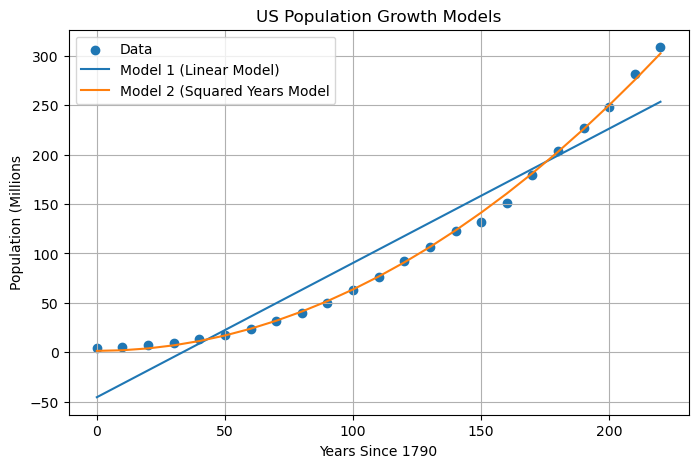

In [15]:
# 1f.

# customize size of plot
# recreate original scatterplot
plt.figure(figsize=(8,5))
plt.scatter(df['years_since_1790'],
            df['us_pop_mil'],
            label='Data')

# model1 prediction
pred1 = model1.predict(X)
plt.plot(df['years_since_1790'],
         pred1,
         label='Model 1 (Linear Model)')

# model2 prediction
pred2 = model2.predict(X2)
plt.plot(df['years_since_1790'],
         pred2,
         label='Model 2 (Squared Years Model')

# create labels
plt.xlabel('Years Since 1790')
plt.ylabel('Population (Millions')
plt.title('US Population Growth Models')
plt.legend()
plt.grid(True)
plt.show()

# The second model, using the squared years, more accurately fits the data.
# This is because the population is growing at an exponential rate, which produces
# an exponential growth curve. The R^2 value for model 2 is higher, almost 100%,
# meaning it almost fits the regression line perfectly.
